In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import lizard
import os
import re
import hashlib
from typing import List, Dict
from tqdm import tqdm
import numpy as np
import json
import ast
import statsmodels.api as sm
from textblob import TextBlob 
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### Dataset

In [2]:
# --- Helper to safely group 1-to-many tables ------------------------------

def group_by_pr(df, pr_key="pr_id", drop_keys=[]):
    """
    Groups a 1-to-many table so each PR has a list of dictionaries.
    Example: comments grouped as list of {user, body, created_at}.
    """
    if df is None or df.empty:
        return df
    
    cols = [c for c in df.columns if c not in drop_keys]
    
    return (
        df.groupby(pr_key)[cols]
        .apply(lambda x: x.to_dict(orient="records"))
        .reset_index()
    )

In [3]:
def agent_data_preprocessing():
    #Download the datasets (Agents)
    pr_df = pq.read_table("hf://datasets/hao-li/AIDev/pull_request.parquet").to_pandas()
    repo_df = pq.read_table("hf://datasets/hao-li/AIDev/repository.parquet").to_pandas()
    user_df = pq.read_table("hf://datasets/hao-li/AIDev/user.parquet").to_pandas()
    # Comments and reviews
    pr_comments_df = pq.read_table("hf://datasets/hao-li/AIDev/pr_comments.parquet").to_pandas()
    pr_reviews_df = pq.read_table("hf://datasets/hao-li/AIDev/pr_reviews.parquet").to_pandas()
    pr_review_comments_df = pq.read_table("hf://datasets/hao-li/AIDev/pr_review_comments_v2.parquet").to_pandas()
    # Commits
    pr_commit_details_df = pq.read_table("hf://datasets/hao-li/AIDev/pr_commit_details.parquet").to_pandas()
    # Task type
    pr_task_type_df = pq.read_table("hf://datasets/hao-li/AIDev/pr_task_type.parquet").to_pandas()
    # Events
    pr_timeline_df = pq.read_table("hf://datasets/hao-li/AIDev/pr_timeline.parquet").to_pandas()
    # Related issues
    related_issue_df = pq.read_table("hf://datasets/hao-li/AIDev/related_issue.parquet").to_pandas()
    issue_df = pq.read_table("hf://datasets/hao-li/AIDev/issue.parquet").to_pandas()


    #Clean and drop columns
    pr_df.drop(columns=["repo_url", "html_url"], inplace=True)
    repo_df.drop(columns=["url", "license"], inplace=True)
    repo_df.rename(columns={"id": "repo_id"}, inplace=True)
    user_df.rename(columns={"id": "user_id"}, inplace=True)
    pr_review_comments_df.rename(columns={"pull_request_review_id": "pr_review_id"}, inplace=True)
    pr_reviews_df.rename(columns={"id": "pr_review_id"}, inplace=True)
    pr_task_type_df.rename(columns={"id": "pr_id"}, inplace=True)
    pr_task_type_df.drop(columns=["reason", "confidence", "title", "agent"], inplace=True)
    issue_df.drop(columns=["html_url"], inplace=True)
    issue_df.rename(columns={"id": "issue_id"}, inplace=True)

    pr_reviews_merged_comments = pr_reviews_df.merge(pr_review_comments_df, on="pr_review_id", how="left", suffixes=("", "_comment"))
    pr_reviews_merged_comments.rename(columns={"id": "pr_review_comment_id"}, inplace=True)
    pr_reviews_merged_comments.drop(columns=["user_comment", "user_type_comment"], inplace=True)
    issue_df = issue_df.merge(related_issue_df, left_on="issue_id", right_on="issue_id", how="inner")
    
    #Merge all Data
    merged = pr_df.merge(repo_df, on="repo_id", how="left", suffixes=("", "_repo"))
    merged = merged.merge(user_df, on="user_id", how="left", suffixes=("", "_user"))
    merged.rename(columns={"id": "pr_id"}, inplace=True)

    # --- Comments, Reviews, Review Comments -----------------------------------

    pr_comments_grouped = group_by_pr(pr_comments_df, "pr_id", drop_keys=["pr_id"])

    pr_reviews_grouped = group_by_pr(pr_reviews_merged_comments, "pr_id", drop_keys=["pr_id"])

    merged = merged.merge(pr_comments_grouped, on="pr_id", how="left") \
               .merge(pr_reviews_grouped, on="pr_id", how="left") 
    # Rename grouped columns for clarity
    merged = merged.rename(columns={
        "0_x": "pr_comments",
        "0_y": "pr_reviews_and_comments",  
    })       
    # --- Commits & commit details --------------------------------------------

    # Group commit list per PR
    pr_commits_grouped = group_by_pr(pr_commit_details_df, "pr_id", drop_keys=["pr_id"])
    merged = merged.merge(pr_commits_grouped, on="pr_id", how="left")
    merged = merged.rename(columns={
    0: "commits"})
    # --- Issues & Related Issues ----------------------------------------------

    issue_grouped = group_by_pr(issue_df, "pr_id", drop_keys=["pr_id"])
    merged = merged.merge(issue_grouped, on="pr_id", how="left")
    merged = merged.rename(columns={
    0: "issues"})
    # ---  Task type annotations -------------------------------------------------

    merged = merged.merge(pr_task_type_df, on="pr_id", how="left")
    merged.rename(columns={"type": "task_type"}, inplace=True)
    # ---  PR timeline -----------------------------------------------------------

    pr_timeline_grouped = group_by_pr(pr_timeline_df, "pr_id", drop_keys=["pr_id"])
    merged = merged.merge(pr_timeline_grouped, on="pr_id", how="left")
    merged.rename(columns={0: "timeline_events"}, inplace=True)

    return merged

In [4]:
def human_data_preprocessing():
    #Download the datasets (Human)
    human_pr_df = pq.read_table("hf://datasets/hao-li/AIDev/human_pull_request.parquet").to_pandas()
    human_pr_task_type_df = pq.read_table("hf://datasets/hao-li/AIDev/human_pr_task_type.parquet").to_pandas()
    # Human Comments and reviews
    human_pr_comments_df = pq.read_table("AIDev_Human_PRs//pr_comments.parquet").to_pandas()
    human_pr_reviews_df = pq.read_table("AIDev_Human_PRs//pr_reviews.parquet").to_pandas()
    human_pr_review_comments_df = pq.read_table("AIDev_Human_PRs//pr_review_comments.parquet").to_pandas()
    # Commits
    human_pr_commit_details_df = pq.read_table("AIDev_Human_PRs//pr_commit_details.parquet").to_pandas()
    # Events
    human_pr_timeline_df = pq.read_table("AIDev_Human_PRs//pr_timeline.parquet").to_pandas()

    # Related issues
    human_related_issue_df = pq.read_table("AIDev_Human_PRs//related_issue.parquet").to_pandas()
    human_issue_df = pq.read_table("AIDev_Human_PRs//issue.parquet").to_pandas()

    human_repo_df = pq.read_table("AIDev_Human_PRs//repository.parquet").to_pandas()


    #Clean and drop columns
    human_pr_df.rename(columns={"id": "pr_id"}, inplace=True)
    human_pr_df.drop(columns=["html_url"], inplace=True)
    human_pr_task_type_df.rename(columns={"type": "task_type", "id": "pr_id"}, inplace=True)
    human_pr_task_type_df.drop(columns=["reason", "confidence", "title", "agent"], inplace=True)
    human_pr_review_comments_df.rename(columns={"pull_request_review_id": "pr_review_id", "id": "pr_review_comment_id"}, inplace=True)
    human_pr_reviews_df.rename(columns={"pull_request_review_id": "pr_review_id"}, inplace=True)
    human_pr_reviews_df.drop(columns=["id"], inplace=True)
    human_issue_df.rename(columns={"id": "issue_id"}, inplace=True)
    human_issue_df = human_issue_df.merge(human_related_issue_df, left_on="issue_id", right_on="issue_id", how="inner")
    human_issue_df.drop(columns=["html_url"], inplace=True)
    human_repo_df.drop(columns=["license"], inplace=True)
    human_repo_df.rename(columns={"id": "repo_id", "url": "repo_url"}, inplace=True)
    
    human_pr_reviews_merged_comments = human_pr_reviews_df.merge(human_pr_review_comments_df, on="pr_review_id", how="left", suffixes=("", "_comment"))

    #Merge all Data
    human_merged = human_pr_df.merge(human_pr_task_type_df, on="pr_id", how="left")
    human_merged = human_merged.merge(human_repo_df, on="repo_url", how="left", suffixes=("", "_repo"))
    human_merged.drop(columns=["repo_url"], inplace=True)

    # --- Comments, Reviews, Review Comments -----------------------------------

    human_pr_comments_grouped = group_by_pr(human_pr_comments_df, "pr_id", drop_keys=["pr_id"])
    human_pr_reviews_grouped = group_by_pr(human_pr_reviews_merged_comments, "pr_id", drop_keys=["pr_id"])
    human_merged = human_merged.merge(human_pr_comments_grouped, on="pr_id", how="left") \
               .merge(human_pr_reviews_grouped, on="pr_id", how="left")   
    # Rename grouped columns for clarity
    human_merged = human_merged.rename(columns={
        "0_x": "pr_comments",
        "0_y": "pr_reviews_and_comments",  
    })    
    # Group commit list per PR
    human_pr_commits_grouped = group_by_pr(human_pr_commit_details_df, "pr_id", drop_keys=["pr_id"])
    human_merged = human_merged.merge(human_pr_commits_grouped, on="pr_id", how="left")
    human_merged = human_merged.rename(columns={
    0: "commits"})    
    # --- Issues & Related Issues ----------------------------------------------
    human_issue_grouped = group_by_pr(human_issue_df, "pr_id", drop_keys=["pr_id"])
    human_merged = human_merged.merge(human_issue_grouped, on="pr_id", how="left") 
    human_merged = human_merged.rename(columns={
    0: "issues"})
    # ---  PR timeline -----------------------------------------------------------
    human_pr_timeline_grouped = group_by_pr(human_pr_timeline_df, "pr_id", drop_keys=["pr_id"])
    human_merged = human_merged.merge(human_pr_timeline_grouped, on="pr_id", how="left")
    human_merged.rename(columns={0: "timeline_events"}, inplace=True)
    human_merged.drop(columns=["is_forked"], inplace=True)

    return human_merged

#### Combining the datasets into one

In [5]:
merged = agent_data_preprocessing()

c:\Users\Strength\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
human_merged = human_data_preprocessing()

In [7]:
merged_data = pd.concat(
    [merged, human_merged],
    ignore_index=True,
    sort=False
)

In [8]:
#remove rows with revert and other
merged_data = merged_data[~merged_data['task_type'].isin(['other', 'revert'])]

In [9]:
# --- Final merged dataset -----------------------------------------------------

print("Final shape:", merged_data.shape)
merged_data.head()

Final shape: (40052, 26)


,pr_id,number,title,body,agent,user_id,user,state,created_at,closed_at,...,login,followers,following,created_at_user,pr_comments,pr_reviews_and_comments,commits,issues,task_type,timeline_events
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,...,weiliu1031,4.0,11.0,2022-07-04T08:56:20Z,"[{'id': 3121064306, 'user': 'sre-ci-robot', 'u...",NaN,[{'sha': 'f528ff4da627bba470791a66534fd47d7165...,NaN,fix,"[{'event': 'review_requested', 'commit_id': No..."
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,...,cm-kojimat,2.0,4.0,2020-03-05T10:01:01Z,NaN,NaN,[{'sha': '39fb52df460140b677b10827c23f119fa3bf...,NaN,refactor,"[{'event': 'committed', 'commit_id': '39fb52df..."
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,...,MSch,161.0,74.0,2008-04-15T20:25:15Z,NaN,"[{'pr_review_id': 3058149254, 'user': 'MSch', ...",[{'sha': '642426fe5678cb3d01d3ef7180c722b6383c...,NaN,feat,"[{'event': 'committed', 'commit_id': '642426fe..."
3,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26T14:07:22Z,2025-07-26T14:45:30Z,...,sugyan,631.0,142.0,2009-05-03T05:25:30Z,NaN,"[{'pr_review_id': 3058232899, 'user': 'copilot...",[{'sha': '64605f5cf35c01a7ab661bb07897e048e2eb...,NaN,feat,"[{'event': 'committed', 'commit_id': '64605f5c..."
4,3265782173,17625,chore: remove HashedPostStateProvider trait,## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...,Claude_Code,47593288,adust09,open,2025-07-26T15:02:48Z,None,...,adust09,44.0,54.0,2019-02-13T09:27:14Z,NaN,NaN,[{'sha': '8f92fe5a23ef41a3c8a57d96dc3c12702e35...,NaN,chore,"[{'event': 'committed', 'commit_id': '8f92fe5a..."


### Exploratory Data Analysis

In [10]:
TASK_CATEGORY_MAP = {
    # Feature & behavior-changing (High risk)
    "feat": ("Feature_Behavior", "High"),
    "fix": ("Feature_Behavior", "High"),
    "perf": ("Feature_Behavior", "High"),

    # Internal code quality (Medium risk)
    "refactor": ("Internal_Quality", "Medium"),
    "test": ("Internal_Quality", "Medium"),

    # Docs & style (Low risk)
    "docs": ("Docs_Style", "Low"),
    "style": ("Docs_Style", "Low"),

    # Infrastructure (Medium risk)
    "build": ("Infrastructure", "Medium"),
    "ci": ("Infrastructure", "Medium"),
    "chore": ("Infrastructure", "Medium"),

}


In [11]:
def safe_parse(val):
    """Parses stringified JSON or lists safely."""
    try:
        if pd.isna(val): return []
        if isinstance(val, list): return val
        return ast.literal_eval(val)
    except:
        try: return json.loads(val)
        except: return []



def get_patch_stats(commits_col):
    data = commits_col if isinstance(commits_col, list) else safe_parse(commits_col)
    if not data:
        return pd.Series([0, 0, 0, 0])

    file_map = {}
    unique_shas = set()
    total_hunks = 0
    code_churn = 0
    
    for item in data:
        sha = item.get('sha')
        fname = item.get('filename')
        adds = float(item.get('additions', 0) or 0)
        dels = float(item.get('deletions', 0) or 0)

        # 1. Total Churn 
        # For each unique commit SHA, we added the commit_stats_total once.
        if sha and sha not in unique_shas:
            code_churn += int(item.get('commit_stats_total', 0) or 0)
            unique_shas.add(sha)

        # 2. For Diff size, we track net additions/deletions per file.
        if fname:
            if fname not in file_map:
                file_map[fname] = {'a': 0, 'd': 0}
            file_map[fname]['a'] += adds
            file_map[fname]['d'] += dels

        # 3. Hunks (Signals Complexity)
        patch = item.get('patch')
        if isinstance(patch, str):
            total_hunks += patch.count('@@ -')

    # To then calculate Logical Diff Size, we take the max of total additions or deletions per file, and sum that across all files in the same PR. 
    logical_diff_size = sum(max(f['a'], f['d']) for f in file_map.values())

    return pd.Series([len(file_map), int(logical_diff_size), int(total_hunks), int(code_churn)])


def actor_type(actor):
    if actor is None:
        return "unknown"
    if "bot" in actor.lower():
        return "bot"
    return "human"


def get_timeline_stats(row):
    timeline_raw = row.get('timeline_events', [])
    reviews_raw = row.get('pr_reviews_and_comments', [])
    
    if not isinstance(timeline_raw, list): timeline_raw = []
    if not isinstance(reviews_raw, list): reviews_raw = []

    events = []
    MEANINGFUL_EVENTS = {"commented", "reviewed", "committed", "review_requested"}
    
    # Automated system bots that shouldn't trigger a "collaboration" timer
    SYSTEM_BOTS = {'claassistant', 'vercel[bot]', 'github-actions[bot]', 'codecov[bot]', 'graphite-app[bot]'}

    for item in timeline_raw:
        event_type = item.get('event')
        if event_type not in MEANINGFUL_EVENTS:
            continue

        actor = item.get('actor')
        t_str = item.get('created_at')
        timeline_commit = item.get('commit_id')

    
        if event_type == "reviewed" and (not t_str or not actor):
            for r in reviews_raw:
                # Check for Human actor in review or comment fields
                is_human = r.get('user_type') == 'User' or r.get('user_type_comment') == 'User'
                if not is_human:
                    continue
                
                # Match by SHA or fallback to first available human review
                is_match = (timeline_commit and r.get('original_commit_id') == timeline_commit)
                
                if is_match or not timeline_commit:
                    # Priority: submitted_at or created_at 
                    t_str = r.get('submitted_at') or r.get('created_at')
                    actor = r.get('user') or r.get('user_comment')
                    if t_str and actor:
                        break 

        if not actor or not isinstance(t_str, str):
            continue

        try:
            dt = datetime.fromisoformat(t_str.replace('Z', '+00:00'))
            events.append({'time': dt, 'actor': actor, 'event': event_type})
        except:
            continue
    
    events.sort(key=lambda x: x['time'])
    reply_times = []
    last_event_by_actor = {}
    
    for e in events:
        current_actor = e['actor']
        current_time = e['time']
        
        # A check for the last event by someone else who is NOT a system bot
        candidates = [
            evt for a_name, evt in last_event_by_actor.items() 
            if a_name != current_actor and a_name.lower() not in SYSTEM_BOTS
        ]
        
        if candidates:
            last_interaction = max(candidates, key=lambda x: x['time'])
            diff_hours = (current_time - last_interaction['time']).total_seconds() / 3600.0
            
            # Filter: > 30 seconds AND < 120 hours (to remove stale/abandoned PR bias)
            if 0.008 < diff_hours < 120.0:
                reply_times.append(diff_hours)
        
        last_event_by_actor[current_actor] = e
        
    if not reply_times:
        return pd.Series([np.nan, np.nan])
        
    # Return Median and mean
    return pd.Series([float(np.median(reply_times)), float(np.mean(reply_times))])


In [12]:
def feature_extraction(merged_data):
    KNOWN_HUMAN_LABELS = {"human"}
    merged_data["created_at"] = pd.to_datetime(merged_data["created_at"])
    merged_data["merged_at"]  = pd.to_datetime(merged_data["merged_at"], errors="coerce")
    merged_data['pr_comments'] = merged_data['pr_comments'].apply(lambda x: [] if isinstance(x, float) and pd.isna(x) else x)
    merged_data['num_comments'] = merged_data['pr_comments'].apply(len)

    merged_data['pr_reviews_and_comments'] = merged_data['pr_reviews_and_comments'].apply(lambda x: [] if isinstance(x, float) and pd.isna(x) else x)
    merged_data['num_reviews'] = merged_data['pr_reviews_and_comments'].apply(len)

    merged_data['commits'] = merged_data['commits'].apply(lambda x: [] if isinstance(x, float) and pd.isna(x) else x)
    merged_data['num_commits'] = merged_data['commits'].apply(len)

    merged_data['issues'] = merged_data['issues'].apply(lambda x: [] if isinstance(x, float) and pd.isna(x) else x)
    merged_data['num_issues'] = merged_data['issues'].apply(len)

    merged_data["time_to_merge"] = (merged_data["merged_at"] - merged_data["created_at"]).dt.total_seconds() / 3600

    merged_data["is_merged"] = merged_data["merged_at"].notna()
    merged_data["is_merged"] = merged_data["is_merged"].astype(int)

    merged_data["author_type"] = merged_data["agent"].apply(
        lambda x: "human" if isinstance(x, str) and x.strip().lower() in KNOWN_HUMAN_LABELS else "agent")
    
    merged_data["author_type"] = merged_data["author_type"].astype("category")
    merged_data["task_category"] = merged_data["task_type"].map(
    lambda x: TASK_CATEGORY_MAP.get(x, ("Unknown", "Unknown"))[0])

    merged_data["risk_level"] = merged_data["task_type"].map(
        lambda x: TASK_CATEGORY_MAP.get(x, ("Unknown", "Unknown"))[1])
    
    merged_data[['files_changed', 'diff_size', 'num_hunks', 'code_churn']] = merged_data['commits'].apply(get_patch_stats)

    merged_data[['median_reply_hours', 'mean_reply_hours']] = merged_data.apply(get_timeline_stats, axis=1)

    return merged_data
    

In [13]:
merged_data = feature_extraction(merged_data)

In [14]:
len(merged_data)

40052

### RQ1: Merge Outcome Analyses

In [15]:
# Isolate merged PRs for the groups
human_ttm = merged_data[(merged_data['author_type'] == 'human') & (merged_data['is_merged'] == True)]['time_to_merge'].dropna()
agent_ttm = merged_data[(merged_data['author_type'] == 'agent') & (merged_data['is_merged'] == True)]['time_to_merge'].dropna()


# --- 1. Statistical Significance for Time to Merge (TTM) ---
u_stat, ttm_p_value = mannwhitneyu(human_ttm, agent_ttm, alternative='two-sided')

# Effect Size for TTM: Rank-Biserial Correlation
n1, n2 = len(human_ttm), len(agent_ttm)
r_biserial = 1 - (2 * u_stat) / (n1 * n2)

# --- 2. Statistical Significance for Merge Rate ---
# Create a contingency table: [[Human_Merged, Human_Not], [Agent_Merged, Agent_Not]]
contingency_table = pd.crosstab(merged_data['author_type'], merged_data['is_merged'])
chi2, mr_p_value, dof, expected = chi2_contingency(contingency_table)

# Effect Size for Merge Rate: Cramér's V
n_total = contingency_table.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(contingency_table.shape) - 1)))

# --- 3. Update author_level Summary Table ---
author_level = (
    merged_data.groupby("author_type")
    .agg(
        total_prs=("pr_id", "count"), 
        merged_prs=("is_merged", "sum"),
        median_ttm=("time_to_merge", "median")
    )
    .assign(merge_rate=lambda df: df["merged_prs"] / df["total_prs"])
)

# Insert the stats into the summary (just for display)
author_level['ttm_p_val'] = [ttm_p_value] * len(author_level)
author_level['ttm_effect_r'] = [r_biserial] * len(author_level)
author_level['merge_rate_p_val'] = [mr_p_value] * len(author_level)
author_level['merge_rate_v'] = [cramers_v] * len(author_level)

print(author_level)

             total_prs  merged_prs  median_ttm  merge_rate  ttm_p_val  \
author_type                                                             
agent            33549       23999    0.045556    0.715342        0.0   
human             6503        5019    4.011667    0.771798        0.0   

             ttm_effect_r  merge_rate_p_val  merge_rate_v  
author_type                                                
agent           -0.545444      1.262564e-20      0.046526  
human           -0.545444      1.262564e-20      0.046526  


C:\Users\Strength\AppData\Local\Temp\ipykernel_47844\342081565.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_data.groupby("author_type")


In [16]:
merged_data.groupby("author_type").agg(
        mean_ttm=("time_to_merge", "mean")
    )

C:\Users\Strength\AppData\Local\Temp\ipykernel_47844\2379798376.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_data.groupby("author_type").agg(


,mean_ttm
author_type,
agent,19.434753
human,63.885369


In [17]:
table = pd.crosstab(merged_data['author_type'], merged_data['is_merged'])

odds_ratio, p_value = stats.fisher_exact(table)
print(f"Odds Ratio: {odds_ratio:.2f}")

Odds Ratio: 1.35


### RQ2: Patch Characteristics

#### Acceptance Rates by Task Type

In [18]:
### Merge rate by category × author type
merge_rate_table = (
    merged_data.groupby(["author_type", "task_category"])
      .agg(
          total_prs=("pr_id", "count"),
          merged_prs=("is_merged", "sum"),
          merge_rate=("is_merged", "mean"),
      )
      .reset_index()
)

C:\Users\Strength\AppData\Local\Temp\ipykernel_47844\2509474527.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_data.groupby(["author_type", "task_category"])


In [19]:
merge_rate_table

,author_type,task_category,total_prs,merged_prs,merge_rate
0,agent,Docs_Style,4075,3413,0.837546
1,agent,Feature_Behavior,22896,15725,0.686801
2,agent,Infrastructure,1934,1410,0.729059
3,agent,Internal_Quality,4644,3451,0.743109
4,human,Docs_Style,578,450,0.778547
5,human,Feature_Behavior,3812,2952,0.774397
6,human,Infrastructure,1561,1202,0.770019
7,human,Internal_Quality,552,415,0.751812


In [20]:
interaction_logit = smf.logit(
    formula="""
        is_merged ~ 
        C(author_type) * C(task_category) +
        num_commits + num_reviews + num_comments
    """,
    data=merged_data
).fit()

print(interaction_logit.summary())


Optimization terminated successfully.
         Current function value: 0.569938
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              is_merged   No. Observations:                40052
Model:                          Logit   Df Residuals:                    40041
Method:                           MLE   Df Model:                           10
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                 0.03178
Time:                        20:43:18   Log-Likelihood:                -22827.
converged:                       True   LL-Null:                       -23576.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercep

In [21]:
# Export covariance matrix to R for plotting
interaction_logit.cov_params().to_csv("cov_matrix.csv")

# Export coefficient vector
interaction_logit.params.to_csv("beta_hat.csv")


#### Cyclomatic Complexity

In [22]:
import csv
import signal

In [ ]:
CODE_EXTS = {'.py', '.js', '.ts', '.swift', '.rs', '.go', '.cpp', '.c', '.h', '.cs', '.java', '.tsx'}
CHECKPOINT_FILE = "pr_complexity_checkpoints.csv"

def compute_cc_single_pr(commits, pr_id):
    if not isinstance(commits, list) or not commits: return 0.0
    
    scores = []
    for commit in commits:
        fname = commit.get('filename') or ''
        if not fname: continue
        
        # Guard: Explicit Metadata/Data Skip (These files are not logical and were causing noise in lizard complexity)
        if any(x in fname.lower() for x in ['lock.yaml', 'lock.json', '.json', '.yaml', '.yml', 'routes.js', 
                                            'routes.d.ts', 'conftest.py', 'index.tsx', '.lockb']):
            continue
            
        # GUARD: Valid Code Extensions Only
        if not any(fname.endswith(ext) for ext in CODE_EXTS): continue
        if "/.claude/" in fname or "/.hive-mind/" in fname: continue
        
        patch = commit.get('patch', '')
        # GUARD: Patch Size (10k chars is ~200-300 lines of real logic)
        if not patch or len(patch) > 10000: continue 
            
        try:
            # Clean patch for Lizard
            code = "\n".join([l[1:] for l in patch.splitlines() if l.startswith('+') and not l.startswith('+++')])
            if code.strip():
                print(f"  -> Analyzing: {fname} (Length: {len(code)})", flush=True)
                analysis = lizard.analyze_file.analyze_source_code(fname, code)
                if analysis.function_list:
                    scores.append(sum(f.cyclomatic_complexity for f in analysis.function_list) / len(analysis.function_list))
                else:
                    scores.append(1.0)
        except: continue
            
    return sum(scores) / len(scores) if scores else 0.0

# --- RESUME CAPABLE LOOP ---
if os.path.exists(CHECKPOINT_FILE):
    processed_df = pd.read_csv(CHECKPOINT_FILE)
    processed_ids = set(processed_df['pr_id'])
    print(f"Resuming: {len(processed_ids)} rows already done.")
else:
    processed_ids = set()

# Filter out what we've already finished
to_process = merged_data[~merged_data['pr_id'].isin(processed_ids)]

with open(CHECKPOINT_FILE, 'a', newline='', encoding='utf-8') as f:
    # Set up the CSV writer
    writer = csv.DictWriter(f, fieldnames=['pr_id', 'avg_cc'])
    
    # Only write the header if the file is empty (size 0)
    if f.tell() == 0:
        writer.writeheader()

    # Iterate through the REMAINING rows
    # We use enumerate just for the flush counter
    for i, (_, row) in tqdm(enumerate(to_process.iterrows()), total=len(to_process)):
        
        # Calculate Score
        cc_score = compute_cc_single_pr(row['commits'], row['pr_id'])
        
        # Write to disk (Fast because file is kept open)
        writer.writerow({'pr_id': row['pr_id'], 'avg_cc': cc_score})
        
        # Flush buffer every 50 rows to ensure data is saved if script crashes
        if i % 50 == 0:
            f.flush()

print("Processing complete!")



In [ ]:
# Load the results
complexity_results = pd.read_csv("pr_complexity_checkpoints.csv")

# Merging back to the original dataframe
# This ensures every PR ID matches its calculated CC score.
merged_data = merged_data.merge(complexity_results, on='pr_id', how='left')

# Fill any skipped PRs with 0 or NaN for statistical analysis
merged_data['avg_cc'] = merged_data['avg_cc'].fillna(0)

In [29]:
# We exclude CC <= 0 to ensure we only analyze actual functional logic
final_analysis_df = merged_data[merged_data['avg_cc'] > 0].copy()

print(f"Removed {len(merged_data) - len(final_analysis_df)} zero-complexity rows.")

# Split into the two groups for comparison
agent_cc = final_analysis_df[final_analysis_df['author_type'] == 'agent']['avg_cc']
human_cc = final_analysis_df[final_analysis_df['author_type'] == 'human']['avg_cc']

print(f"Sample size - Agents: {len(agent_cc)}, Humans: {len(human_cc)}")

Removed 12889 zero-complexity rows.
Sample size - Agents: 23030, Humans: 4133


In [31]:
#  Calculate Means
mean_a = agent_cc.mean()
mean_h = human_cc.mean()

print(mean_a, mean_h)

1.8506941296785593 1.330013969355441


In [30]:
#  Perform Welch's t-test (equal_var=False) Used this
t_stat, p_val_t = stats.ttest_ind(agent_cc, human_cc, equal_var=False)

# 4. Calculate Cohen's d for Effect Size
# This measures how many standard deviations the means differ by
n1, n2 = len(agent_cc), len(human_cc)
s1, s2 = agent_cc.std(), human_cc.std()
pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = (agent_cc.mean() - human_cc.mean()) / pooled_std

print(f"--- Welch's T-Test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val_t:.4e}")
print(f"Cohen's d: {cohens_d:.4f}")

--- Welch's T-Test Results ---
T-statistic: 26.9236
P-value: 1.5967e-155
Cohen's d: 0.2727


#### Breadth and Structural complexity of Files

In [34]:
# Prepare Target Variables
merged_data['is_merged_binary'] = merged_data['is_merged'].astype(int) # Target 1

features = ['files_changed', 'diff_size', 'code_churn', 'mean_reply_hours', 'median_reply_hours',
            'num_comments', 'num_hunks']
merged_data[features] = merged_data[features].fillna(0)

In [87]:
print(merged_data.groupby('author_type')[features].mean())

             files_changed    diff_size   code_churn  mean_reply_hours  \
author_type                                                              
agent            17.134907  1530.672896  3242.209008          1.473832   
human            34.526526  2922.718130  7027.306628          2.994082   

             median_reply_hours  num_comments  num_hunks  
author_type                                               
agent                  1.230010      1.164416  37.472890  
human                  2.760103      1.707827  91.983392  


C:\Users\Strength\AppData\Local\Temp\ipykernel_47844\817133174.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(merged_data.groupby('author_type')[features].mean())


In [89]:
print(merged_data.groupby('author_type')[features].median())

             files_changed  diff_size  code_churn  mean_reply_hours  \
author_type                                                           
agent                  3.0       79.0        95.0               0.0   
human                  4.0       71.0        95.0               0.0   

             median_reply_hours  num_comments  num_hunks  
author_type                                               
agent                       0.0           0.0        7.0  
human                       0.0           1.0        9.0  


C:\Users\Strength\AppData\Local\Temp\ipykernel_47844\3599463263.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(merged_data.groupby('author_type')[features].median())


In [90]:
# --- 4. Comparison (Agent vs Human) ---

# Metrics to compare
metrics = {
    'Patch Complexity': ['code_churn', 'files_changed', 'diff_size', 'num_hunks'],
    'Collaboration': ['mean_reply_hours', 'median_reply_hours', 'num_comments', 'num_commits']
}
results = []

print("\n--- Statistical Comparison (Human vs Agent) ---")
for category, metric_list in metrics.items():
    for metric in metric_list:
        # Separate groups
        agent_vals = merged_data[merged_data['author_type'] == 'agent'][metric].dropna()
        human_vals = merged_data[merged_data['author_type'] == 'human'][metric].dropna() # or whatever your label is
        
        if len(agent_vals) == 0 or len(human_vals) == 0:
            print(f"Skipping {metric}: Missing data for one group.")
            continue

        # Mann-Whitney U Test
        stat, p_value = stats.mannwhitneyu(agent_vals, human_vals, alternative='two-sided')
        
        results.append({
            'Category': category,
            'Metric': metric,
            'Agent Median': agent_vals.median(),
            'Human Median': human_vals.median(),
            'p-value': p_value,
            'Significant': p_value < 0.05
        })

# Display Results Table
results_merged_data = pd.DataFrame(results)
print(results_merged_data[['Category', 'Metric', 'Agent Median', 'Human Median', 'p-value', 'Significant']].to_string(index=False))



--- Statistical Comparison (Human vs Agent) ---
        Category             Metric  Agent Median  Human Median       p-value  Significant
Patch Complexity         code_churn          95.0          95.0  2.153151e-01        False
Patch Complexity      files_changed           3.0           4.0  1.201104e-23         True
Patch Complexity          diff_size          79.0          71.0  2.130356e-01        False
Patch Complexity          num_hunks           7.0           9.0  1.067949e-51         True
   Collaboration   mean_reply_hours           0.0           0.0  8.453661e-39         True
   Collaboration median_reply_hours           0.0           0.0  1.357359e-41         True
   Collaboration       num_comments           0.0           1.0 2.079558e-261         True
   Collaboration        num_commits           4.0           5.0  4.697741e-20         True


### RQ3: Psycholinguistic Analyses

In [ ]:
def clean_text_for_liwc(text):
    """
    Helper function to clean text:
    1. returns None if text is not a string (e.g., NaN or None)
    2. Replaces newlines and carriage returns with spaces
    """
    if not isinstance(text, str):
        return None
    
    # Replace line breaks with space to prevent CSV structure breaking
    cleaned = text.replace('\n', ' ').replace('\r', ' ')
    
    # Optional: Replace multiple spaces with a single space for cleaner data
    cleaned = ' '.join(cleaned.split())
    
    return cleaned

# List to hold our new flattened rows
flattened_data = []

# 2. Iterate through each row of the original dataset
print("Processing rows...")

for index, row in merged_data.iterrows():
    pr_id = row['pr_id']
    author_type = row['author_type']
    
    # For the PR comments column, we extract just the body field.
    # Convert stringified list to actual list
    try:
        pr_comments_raw = row['pr_comments']
        # If it's already a list, use it; if string, parse it; otherwise empty list
        if isinstance(pr_comments_raw, str):
            pr_comments = ast.literal_eval(pr_comments_raw)
        elif isinstance(pr_comments_raw, list):
            pr_comments = pr_comments_raw
        else:
            pr_comments = []
    except (ValueError, SyntaxError):
        pr_comments = []

    # Iterate through the list of dictionaries
    if isinstance(pr_comments, list):
        for comment in pr_comments:
            raw_body = comment.get('body')
            cleaned_body = clean_text_for_liwc(raw_body)
            
            if cleaned_body: # Only add if there is text
                flattened_data.append({
                    'pr_id': pr_id,
                    'author_type': author_type,
                    'source_type': 'pr_comment',
                    'user': comment.get('user'),
                    'user_type': comment.get('user_type'),
                    'text_to_analyze': cleaned_body
                })

    # For the Pr reviews and review comments column, there are two text fields: 
    # body (general review text) and body_comment (specific inline code comments). We want to extract both separately.
    try:
        reviews_raw = row['pr_reviews_and_comments']
        if isinstance(reviews_raw, str):
            reviews = ast.literal_eval(reviews_raw)
        elif isinstance(reviews_raw, list):
            reviews = reviews_raw
        else:
            reviews = []
    except (ValueError, SyntaxError):
        reviews = []

    if isinstance(reviews, list):
        for review in reviews:
            # 1. Extract and clean 'body' (general review text)
            raw_body = review.get('body')
            cleaned_body = clean_text_for_liwc(raw_body)
            
            if cleaned_body:
                flattened_data.append({
                    'pr_id': pr_id,
                    'author_type': author_type,
                    'source_type': 'review_body',
                    'user': review.get('user'),
                    'user_type': review.get('user_type'),
                    'text_to_analyze': cleaned_body
                })
            
            # 2. Extract and clean 'body_comment' (specific inline code comments)
            raw_inline = review.get('body_comment')
            cleaned_inline = clean_text_for_liwc(raw_inline)
            
            if cleaned_inline:
                flattened_data.append({
                    'pr_id': pr_id,
                    'author_type': author_type,
                    'source_type': 'review_inline_comment',
                    'user': review.get('user'),
                    'user_type': review.get('user_type'),
                    'text_to_analyze': cleaned_inline
                })

# 3. Create the new clean DataFrame
liwc_data = pd.DataFrame(flattened_data)

# 4. Save to CSV for LIWC
output_filename = 'liwc_ready_data.csv'
liwc_data.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"Done! Processed {len(merged_data)} original rows.")
print(f"Created {len(liwc_data)} rows for LIWC analysis.")
print(f"File saved as: {output_filename}")

Processing rows...
Done! Processed 40052 original rows.
Created 161483 rows for LIWC analysis.
File saved as: liwc_ready_data.csv


In [ ]:
#After running the LIWC analysis externally, we load the results back into Python for further analysis and merging with our original dataset.
liwc_results = pd.read_csv("LIWC_results_reduced.csv")

In [93]:
liwc_results.columns

Index(['pr_id', 'author_type', 'source_type', 'user', 'user_type',
       'text_to_analyze', 'Segment', 'WC', 'Analytic', 'Clout', 'Authentic',
       'Tone', 'WPS', 'BigWords', 'Dic', 'Cognition', 'allnone', 'cogproc',
       'insight', 'cause', 'discrep', 'tentat', 'certitude', 'differ',
       'memory', 'Affect', 'tone_pos', 'tone_neg', 'emotion', 'emo_pos',
       'emo_neg', 'emo_anx', 'emo_anger', 'emo_sad', 'Social', 'socbehav',
       'prosocial', 'polite', 'conflict', 'moral', 'comm', 'need', 'want',
       'acquire', 'lack', 'fulfill', 'fatigue', 'reward', 'risk', 'curiosity',
       'allure', 'Perception', 'attention', 'motion', 'space', 'visual',
       'auditory', 'feeling', 'time', 'focuspast', 'focuspresent',
       'focusfuture', 'Conversation', 'netspeak', 'assent', 'nonflu',
       'filler'],
      dtype='object')

#### Collaboration signals (PR author type vs Commenter type)

In [94]:
# Count frequencies
freq_table = (
    liwc_results
    .groupby(["author_type", "user_type"])
    .size()
    .reset_index(name="count")
)

# Pivot for readability
pivot_table = freq_table.pivot(
    index="author_type",
    columns="user_type",
    values="count"
).fillna(0).astype(int)

normalized = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100
normalized.round(2)

user_type,Bot,User
author_type,,
agent,61.46,38.54
human,51.42,48.58


In [95]:
contingency = pd.crosstab(
    liwc_results["author_type"],   # PR author: human vs agent
    liwc_results["user_type"]      # commenter: User vs Bot
)

contingency

user_type,Bot,User
author_type,,
agent,48257,30255
human,42618,40260


In [96]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

chi2, p_value, dof


(np.float64(1652.1593532888219), np.float64(0.0), 1)

In [126]:
# Extract counts
a = contingency.loc["human", "Bot"]
b = contingency.loc["human", "User"]
c = contingency.loc["agent", "Bot"]
d = contingency.loc["agent", "User"]

odds_ratio = (c / d) / (a / b)
odds_ratio


np.float64(1.5067592552328624)

#### Sentiment Analysis

In [ ]:
#We remove bot comments to focus on sentiment from human reviewers only.
liwc_results_sentiment = liwc_results[liwc_results['user_type'] !='Bot'].reset_index(drop=True)

In [100]:
liwc_metrics = [
    'Tone',       # Emotional Tone (Higher = More positive)
    'Analytic',   # Logical thinking (Higher = More formal/rigid)
    'Clout',      # Social Status (Higher = Dominant/Confident)
    'Authentic',  # Honesty/Disclosure
    'WC',         # Word Count
    'polite',     # Politeness (please, thanks)
    'insight',    # Teaching/Explaining (think, know, consider)
    'cause',      # Reasoning (because, effect)
    'emo_anger',  # Anger
    'emo_anx',    # Anxiety
    'Social'      # Social references
]

In [103]:
liwc_category = {
    # Style Indicators (High-Level Summary)
    "Tone": ("Style Indicators"),
    "Analytic": ("Style Indicators"),
    "Clout": ("Style Indicators"),
    "Authentic": ("Style Indicators"),
    "WC": ("Style Indicators"),
    

    #Psychological Processes
    "polite": ("Psychological Processes"),
    "insight": ("Psychological Processes"),
    "cause": ("Psychological Processes"),
    "emo_anger": ("Psychological Processes"),
    "emo_anx": ("Psychological Processes"),
    "Social" : ("Psychological Processes"),

    # Extended Linguistic Categories
    
}

In [ ]:
#We group by PR_ID to get one score per PR
# Since a PR might have 10 comments, we take the MEAN (average) of those comments
# to get the overall "vibe" of that PR.
pr_level_data = liwc_results_sentiment.groupby(['pr_id', 'author_type'])[liwc_metrics].mean().reset_index()


In [144]:
# Split the data into two groups
agent_prs = pr_level_data[pr_level_data['author_type'] == 'agent']
human_prs = pr_level_data[pr_level_data['author_type'] != 'agent']

def calculate_cohens_d(group1, group2):
    """Calculates Cohen's d for two independent groups."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std != 0 else 0

# 1. Reverse the dictionary to group metrics by their category
categories = {}
for metric, cat in liwc_category.items():
    if cat not in categories:
        categories[cat] = []
    categories[cat].append(metric)

# 2. Print Header
print(f"{'Category':<30} {'Agent':<10} {'Human':<10} {'Δ%':<10} {'p':<10} {'d'}")
print("-" * 85)

# 3. Iterate through categories and metrics
for cat_name, metrics in categories.items():
    # Print the Section Subheading (e.g., Style Indicators)
    print(f"**{cat_name}**")
    
    for metric in metrics:
        # Clean data for current metric
        a_data = agent_prs[metric].dropna()
        h_data = human_prs[metric].dropna()
        
        # Calculate Stats
        a_mean = a_data.mean()
        h_mean = h_data.mean()
        delta_pct = ((a_mean - h_mean) / h_mean) * 100 if h_mean != 0 else 0
        #_, p_val = stats.ttest_ind(a_data, h_data, equal_var=False)
        u_stat, p_val = stats.mannwhitneyu(a_data, h_data, alternative='two-sided')
        d = calculate_cohens_d(a_data, h_data)
        
        # Format P-value for the table
        p_str = f"{p_val:.3f}" if p_val >= 0.001 else "< .001"
        
        # Print the row
        print(f"  {metric:<28} {a_mean:<10.2f} {h_mean:<10.2f} {delta_pct:>+7.1f}%   {p_str:<10} {d:.2f}")
    print() # Add a spacer between sections

Category                       Agent      Human      Δ%         p          d
-------------------------------------------------------------------------------------
**Style Indicators**
  Tone                         61.06      65.62         -7.0%   < .001     -0.14
  Analytic                     56.79      54.19         +4.8%   < .001     0.09
  Clout                        39.28      41.85         -6.1%   < .001     -0.08
  Authentic                    45.68      44.86         +1.8%   0.372      0.03
  WC                           49.19      63.59        -22.6%   < .001     -0.09

**Psychological Processes**
  polite                       1.96       2.13          -7.9%   < .001     -0.02
  insight                      2.68       2.85          -5.8%   < .001     -0.03
  cause                        2.49       2.84         -12.6%   < .001     -0.09
  emo_anger                    0.02       0.02          +8.3%   0.019      0.01
  emo_anx                      0.01       0.02         -35.8%

In [ ]:
#Model: OLS regression for each LIWC metric with author_type as the main predictor and code_churn as a control variable

# 1. Prepare the data
df_reg = merged_data.copy()
df_reg['is_agent'] = (df_reg['author_type'] == 'agent').astype(int)

# 2. Define the metrics to test (based on your categories)
#metrics_to_test = ["Analytic", "Tone", "Social", "Clout", "polite"]

print(f"{'Metric':<15} | {'Agent Coef':<12} | {'P-Value':<10} | {'Impact'}")
print("-" * 60)

for metric in liwc_metrics:
    # X includes the intercept, the author type, and code churn as a control
    X = df_reg[['is_agent', 'code_churn']]
    X = sm.add_constant(X)
    y = df_reg[metric]
    
    # Fit Ordinary Least Squares (OLS) regression
    model = sm.OLS(y, X, missing='drop').fit()
    
    coef = model.params['is_agent']
    p_val = model.pvalues['is_agent']
    sig = "Significant" if p_val < 0.05 else "Not sig"
    
    print(f"{metric:<15} | {coef:<12.2f} | {p_val:<10.4f} | {sig}")
    

Metric          | Agent Coef   | P-Value    | Impact
------------------------------------------------------------
Tone            | -4.67        | 0.0000     | Significant
Analytic        | 2.67         | 0.0001     | Significant
Clout           | -2.65        | 0.0005     | Significant
Authentic       | 0.91         | 0.2174     | Not sig
WC              | -13.18       | 0.0001     | Significant
polite          | -0.17        | 0.3224     | Not sig
insight         | -0.16        | 0.2490     | Not sig
cause           | -0.34        | 0.0002     | Significant
emo_anger       | 0.00         | 0.7144     | Not sig
emo_anx         | -0.01        | 0.1733     | Not sig
Social          | -0.91        | 0.0030     | Significant


In [ ]:
# Add linguistic data to main data
pr_level_data = pr_level_data.drop(columns=['author_type'])  # Drop author_type to avoid confusion in merge
merged_data = merged_data.merge(pr_level_data, on='pr_id', how='left')

#### KDE(Density Plot)

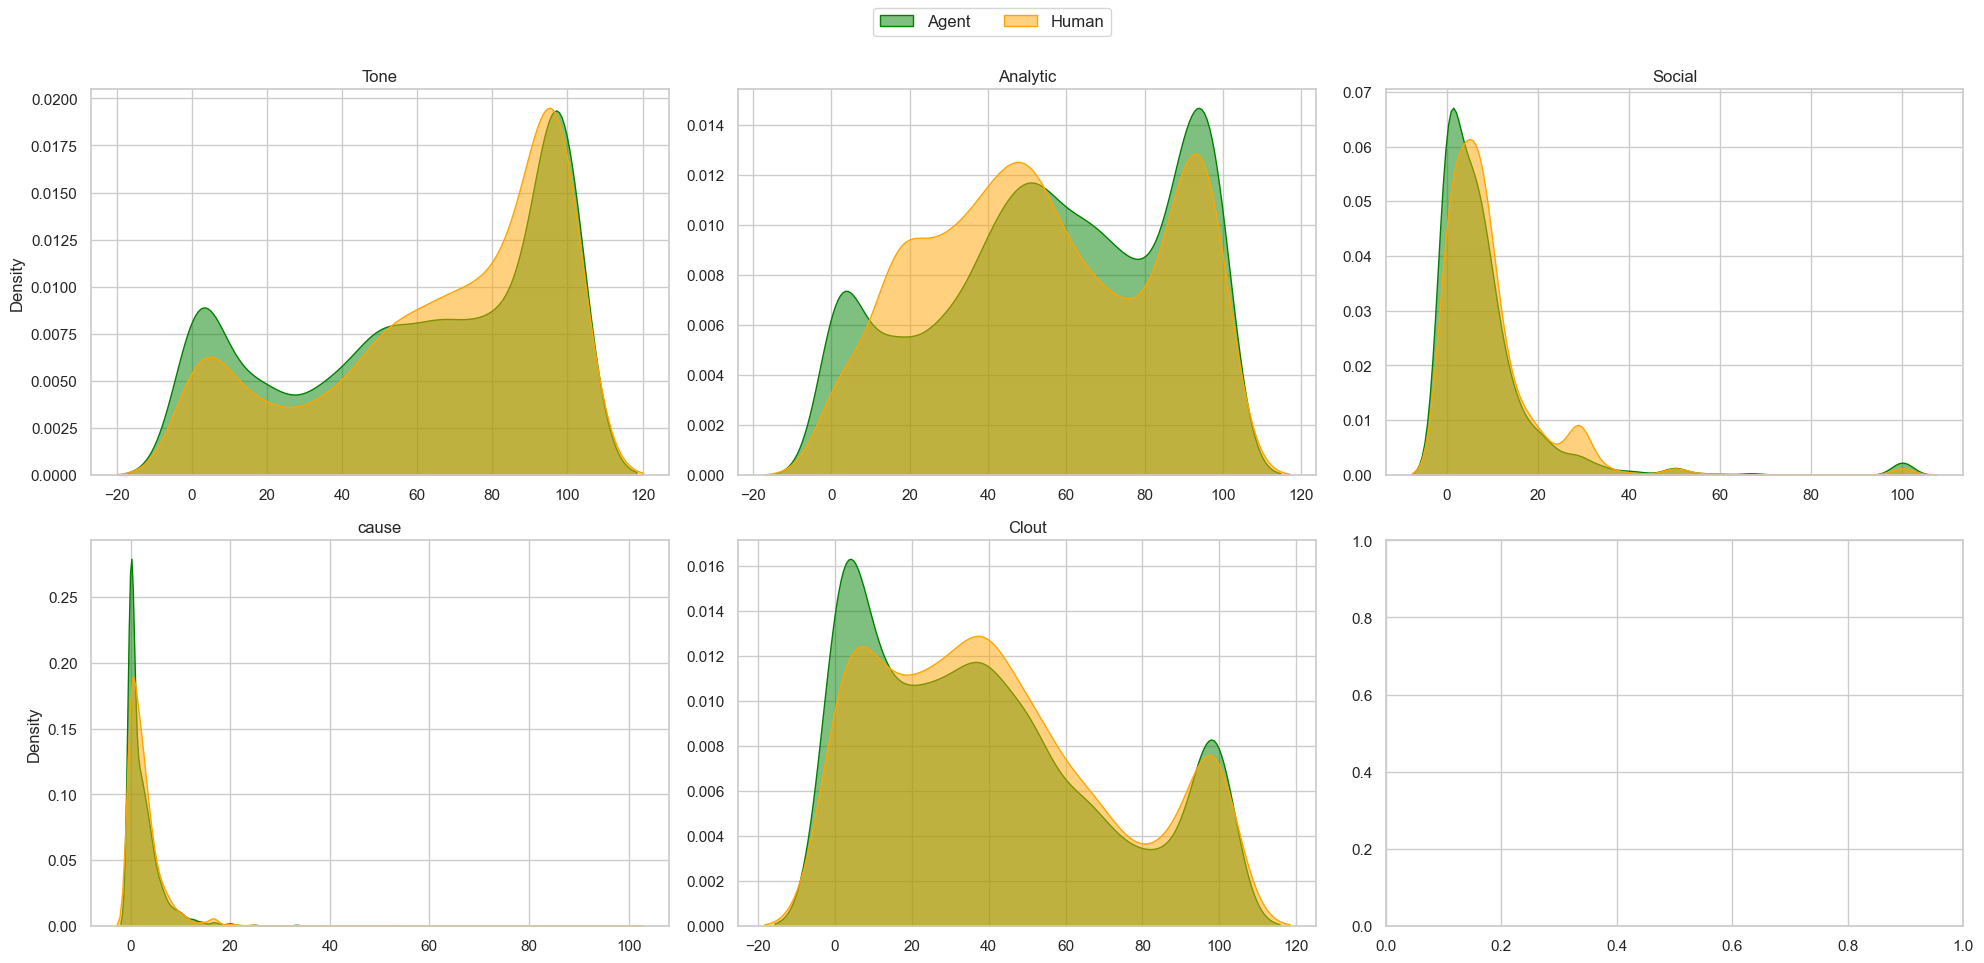

In [149]:
# Your full list of metrics
metrics_to_plot = ["Tone", "Analytic", "Social", "cause", "Clout"]

# Set style
sns.set_theme(style="whitegrid")

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten() # Flatten to 1D array for easy looping

for i, metric in enumerate(metrics_to_plot):
    # Plot distributions
    sns.kdeplot(data=agent_prs, x=metric, fill=True, color="green", 
                label="Agent", ax=axes[i], alpha=0.5)
    sns.kdeplot(data=human_prs, x=metric, fill=True, color="orange", 
                label="Human", ax=axes[i], alpha=0.5)
    
    axes[i].set_title(f"{metric}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density" if i % 3 == 0 else "") # Label Y only on the left column

# Single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Make room for the legend
plt.show()

#### Explanatory Model for Merge Outcome

**Model**: $\text{P(Merged)} = \text{logit}^{-1}(\beta_0 + \beta_1 \cdot \text{AuthorType} + \beta_2 \cdot \text{Tone} + \beta_3 \cdot \text{Analytic} + \beta_4 \cdot \text{TaskType} + \text{Controls})$

We include this to test whether author type, reviewer sentiment, and task characteristics jointly explain merge outcomes and we then compare against another model that doesn't include psycholiguistic analysis.

In [123]:
# =============================================================================
# EXPLANATORY MODEL: Merge Outcome ~ Author Type + Tone + Analytic + Task Type
# =============================================================================
print("=" * 70)
print("LOGISTIC REGRESSION: Explaining Merge Outcomes")
print("=" * 70)

# Prepare model data
model_data = merged_data.dropna(subset=['Tone', 'Analytic', 'task_category', 'is_merged', 'avg_cc']).copy()

# Ensure is_merged is integer
model_data['is_merged'] = model_data['is_merged'].astype(int)

print(f"Sample size for model: {len(model_data)} PRs")
print(f"  - Agent: {(model_data['author_type'] == 'agent').sum()}")
print(f"  - Human: {(model_data['author_type'] == 'human').sum()}")

# Fit the explanatory model
explanatory_model = smf.logit(
    formula='''
        is_merged ~ 
        C(author_type, Treatment(reference='agent')) + 
        Tone + 
        Analytic + 
        C(task_category) +
        avg_cc + 
        diff_size + 
        num_commits
    ''',
    data=model_data
).fit(disp=0)

print("\n" + "=" * 70)
print(explanatory_model.summary())

LOGISTIC REGRESSION: Explaining Merge Outcomes
Sample size for model: 6285 PRs
  - Agent: 4345
  - Human: 1940

                           Logit Regression Results                           
Dep. Variable:              is_merged   No. Observations:                 6285
Model:                          Logit   Df Residuals:                     6275
Method:                           MLE   Df Model:                            9
Date:                Tue, 10 Feb 2026   Pseudo R-squ.:                 0.03645
Time:                        01:53:18   Log-Likelihood:                -4065.3
converged:                       True   LL-Null:                       -4219.1
Covariance Type:            nonrobust   LLR p-value:                 6.434e-61
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept   

In [125]:
# =============================================================================
# MODEL DIAGNOSTICS & COMPARISON
# =============================================================================
print("\n" + "=" * 70)
print("MODEL COMPARISON: Does adding psycholinguistics improve prediction?")
print("=" * 70)

# Base model (without LIWC)
base_model = smf.logit(
    formula='is_merged ~ C(author_type) + C(task_category) + avg_cc + diff_size + num_commits',
    data=model_data
).fit(disp=0)

# Full model (with LIWC)
full_model = explanatory_model  # already fitted above

print(f"\nBase Model (no LIWC):")
print(f"  AIC: {base_model.aic:.2f}")
print(f"  BIC: {base_model.bic:.2f}")
print(f"  Pseudo R²: {base_model.prsquared:.4f}")

print(f"\nFull Model (with Tone + Analytic):")
print(f"  AIC: {full_model.aic:.2f}")
print(f"  BIC: {full_model.bic:.2f}")
print(f"  Pseudo R²: {full_model.prsquared:.4f}")

# Likelihood Ratio Test
lr_stat = 2 * (full_model.llf - base_model.llf)
lr_df = len(full_model.params) - len(base_model.params)
lr_pval = 1 - stats.chi2.cdf(lr_stat, lr_df)

print(f"\nLikelihood Ratio Test:")
print(f"  χ² = {lr_stat:.2f}, df = {lr_df}, p = {lr_pval:.4e}")
if lr_pval < 0.05:
    print("  → Adding LIWC variables SIGNIFICANTLY improves model fit")
else:
    print("  → LIWC variables do NOT significantly improve model fit")


MODEL COMPARISON: Does adding psycholinguistics improve prediction?

Base Model (no LIWC):
  AIC: 8195.92
  BIC: 8249.89
  Pseudo R²: 0.0306

Full Model (with Tone + Analytic):
  AIC: 8150.64
  BIC: 8218.10
  Pseudo R²: 0.0365

Likelihood Ratio Test:
  χ² = 49.28, df = 2, p = 1.9902e-11
  → Adding LIWC variables SIGNIFICANTLY improves model fit


### Replication of RQ1 on a data subset with >= 500 stars

In [15]:
sub_merged = merged_data[merged_data['stars']>= 500]

In [16]:
len(sub_merged)

18847

In [18]:
KNOWN_HUMAN_LABELS = {"human"}
sub_merged["author_type"] = sub_merged["agent"].apply(
    lambda x: "human" if isinstance(x, str) and x.strip().lower() in KNOWN_HUMAN_LABELS else "agent"
)
sub_merged["author_type"] = sub_merged["author_type"].astype("category")

agent_merge_summary = (
    sub_merged.groupby("agent", dropna=False)
    .agg(total_prs=("pr_id", "count"), merged_prs=("is_merged", "sum"))
    .assign(merge_rate=lambda df: df["merged_prs"] / df["total_prs"])
    .sort_values("total_prs", ascending=False)
)

agent_merge_summary

C:\Users\Strength\AppData\Local\Temp\ipykernel_38816\4070141771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_merged["author_type"] = sub_merged["agent"].apply(
C:\Users\Strength\AppData\Local\Temp\ipykernel_38816\4070141771.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_merged["author_type"] = sub_merged["author_type"].astype("category")


,total_prs,merged_prs,merge_rate
agent,,,
Human,6503,5019,0.771798
OpenAI_Codex,4297,2833,0.659297
Devin,3485,1811,0.519656
Copilot,3368,1425,0.423100
Cursor,918,567,0.617647
Claude_Code,276,130,0.471014


In [19]:
# Isolate merged PRs for the groups
human_ttm = sub_merged[(sub_merged['author_type'] == 'human') & (sub_merged['is_merged'] == True)]['time_to_merge'].dropna()
agent_ttm = sub_merged[(sub_merged['author_type'] == 'agent') & (sub_merged['is_merged'] == True)]['time_to_merge'].dropna()


# --- 1. Statistical Significance for Time to Merge (TTM) ---
u_stat, ttm_p_value = mannwhitneyu(human_ttm, agent_ttm, alternative='two-sided')

# Effect Size for TTM: Rank-Biserial Correlation
n1, n2 = len(human_ttm), len(agent_ttm)
r_biserial = 1 - (2 * u_stat) / (n1 * n2)

# --- 2. Statistical Significance for Merge Rate ---
# Create a contingency table: [[Human_Merged, Human_Not], [Agent_Merged, Agent_Not]]
contingency_table = pd.crosstab(sub_merged['author_type'], sub_merged['is_merged'])
chi2, mr_p_value, dof, expected = chi2_contingency(contingency_table)

# Effect Size for Merge Rate: Cramér's V
n_total = contingency_table.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(contingency_table.shape) - 1)))

# --- 3. Update author_level Summary Table ---
author_level = (
    sub_merged.groupby("author_type")
    .agg(
        total_prs=("pr_id", "count"), 
        merged_prs=("is_merged", "sum"),
        median_ttm=("time_to_merge", "median")
    )
    .assign(merge_rate=lambda df: df["merged_prs"] / df["total_prs"])
)

# Insert the stats into the summary (just for display)
author_level['ttm_p_val'] = [ttm_p_value] * len(author_level)
author_level['ttm_effect_r'] = [r_biserial] * len(author_level)
author_level['merge_rate_p_val'] = [mr_p_value] * len(author_level)
author_level['merge_rate_v'] = [cramers_v] * len(author_level)

print(author_level)

             total_prs  merged_prs  median_ttm  merge_rate     ttm_p_val  \
author_type                                                                
agent            12344        6766    1.862639    0.548121  7.753946e-26   
human             6503        5019    4.011667    0.771798  7.753946e-26   

             ttm_effect_r  merge_rate_p_val  merge_rate_v  
author_type                                                
agent           -0.113047     1.369137e-199      0.219558  
human           -0.113047     1.369137e-199      0.219558  


C:\Users\Strength\AppData\Local\Temp\ipykernel_38816\584883019.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_merged.groupby("author_type")


In [20]:
sub_merged.groupby("author_type").agg(
        mean_ttm=("time_to_merge", "mean")
    )

C:\Users\Strength\AppData\Local\Temp\ipykernel_38816\2087583511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_merged.groupby("author_type").agg(


,mean_ttm
author_type,
agent,46.036633
human,63.885369
